In [1]:
import pandas as pd 

In [2]:
wealth_25600 = pd.read_parquet("/share/pierson/matt/mllmsci/outputs/pairwise/wealth_tester_large_20260304_183001.parquet")

In [3]:
wealth_25600

,pair_id,canonical_pair_id,repeat_idx,sample_id_a,sample_id_b,image_path_a,image_path_b,presented_left_path,presented_right_path,presented_order,...,params,__inference_error__,answer,metadata,model_response,presented_answer,presented_label,presented_score,relative_label,relative_score
0,pair_00000043,pair_00000043,0,W0E65DUU_F,W0EHO4UN_B,/scratch/mwf62/cyclomedia/manhattan_2025_1k/W0...,/scratch/mwf62/cyclomedia/manhattan_2025_1k/W0...,/scratch/mwf62/cyclomedia/manhattan_2025_1k/W0...,/scratch/mwf62/cyclomedia/manhattan_2025_1k/W0...,B_then_A,...,"SamplingParams(n=1, presence_penalty=0.0, freq...",None,More,"{'processing_time': 84.38629102706909, 'ts_end...",More,More,More,1,Less,-1
1,pair_00000044,pair_00000044,0,W0EM2LAC_F,W0EHOWYB_R,/scratch/mwf62/cyclomedia/manhattan_2025_1k/W0...,/scratch/mwf62/cyclomedia/manhattan_2025_1k/W0...,/scratch/mwf62/cyclomedia/manhattan_2025_1k/W0...,/scratch/mwf62/cyclomedia/manhattan_2025_1k/W0...,A_then_B,...,"SamplingParams(n=1, presence_penalty=0.0, freq...",None,Less,"{'processing_time': 84.36391496658325, 'ts_end...",Less,Less,Less,-1,Less,-1
2,pair_00000045,pair_00000045,0,W0ED2NAK_L,W0ECVT26_L,/scratch/mwf62/cyclomedia/manhattan_2025_1k/W0...,/scratch/mwf62/cyclomedia/manhattan_2025_1k/W0...,/scratch/mwf62/cyclomedia/manhattan_2025_1k/W0...,/scratch/mwf62/cyclomedia/manhattan_2025_1k/W0...,B_then_A,...,"SamplingParams(n=1, presence_penalty=0.0, freq...",None,More,"{'processing_time': 84.34934496879578, 'ts_end...",More,More,More,1,Less,-1
3,pair_00000046,pair_00000046,0,W0ECVCYH_R,W0EP25QM_B,/scratch/mwf62/cyclomedia/manhattan_2025_1k/W0...,/scratch/mwf62/cyclomedia/manhattan_2025_1k/W0...,/scratch/mwf62/cyclomedia/manhattan_2025_1k/W0...,/scratch/mwf62/cyclomedia/manhattan_2025_1k/W0...,A_then_B,...,"SamplingParams(n=1, presence_penalty=0.0, freq...",None,More,"{'processing_time': 84.33613085746765, 'ts_end...",More,More,More,1,More,1
4,pair_00000047,pair_00000047,0,W0EHMZ10_R,W0ECRBHR_L,/scratch/mwf62/cyclomedia/manhattan_2025_1k/W0...,/scratch/mwf62/cyclomedia/manhattan_2025_1k/W0...,/scratch/mwf62/cyclomedia/manhattan_2025_1k/W0...,/scratch/mwf62/cyclomedia/manhattan_2025_1k/W0...,B_then_A,...,"SamplingParams(n=1, presence_penalty=0.0, freq...",None,More,"{'processing_time': 84.32255601882935, 'ts_end...",More,More,More,1,Less,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
484795,pair_00318939_r1,pair_00318939,1,W0ECI34F_B,W0EHMYLW_B,/scratch/mwf62/cyclomedia/manhattan_2025_1k/W0...,/scratch/mwf62/cyclomedia/manhattan_2025_1k/W0...,/scratch/mwf62/cyclomedia/manhattan_2025_1k/W0...,/scratch/mwf62/cyclomedia/manhattan_2025_1k/W0...,B_then_A,...,"SamplingParams(n=1, presence_penalty=0.0, freq...",None,More,"{'processing_time': 2.9654579162597656, 'ts_en...",More,More,More,1,Less,-1
484796,pair_00219635_r1,pair_00219635,1,W0ECIPUJ_R,W0ECI1M6_L,/scratch/mwf62/cyclomedia/manhattan_2025_1k/W0...,/scratch/mwf62/cyclomedia/manhattan_2025_1k/W0...,/scratch/mwf62/cyclomedia/manhattan_2025_1k/W0...,/scratch/mwf62/cyclomedia/manhattan_2025_1k/W0...,A_then_B,...,"SamplingParams(n=1, presence_penalty=0.0, freq...",None,More,"{'processing_time': 2.9575300216674805, 'ts_en...",More,More,More,1,More,1
484797,pair_00340841_r1,pair_00340841,1,W0ECRCVU_B,W0ECL30V_L,/scratch/mwf62/cyclomedia/manhattan_2025_1k/W0...,/scratch/mwf62/cyclomedia/manhattan_2025_1k/W0...,/scratch/mwf62/cyclomedia/manhattan_2025_1k/W0...,/scratch/mwf62/cyclomedia/manhattan_2025_1k/W0...,B_then_A,...,"SamplingParams(n=1, presence_penalty=0.0, freq...",None,Less,"{'processing_time': 2.9473650455474854, 'ts_en...",Less,Less,Less,-1,More,1
484798,pair_00054826_r1,pair_00054826,1,W0ECPMOY_L,W0ECRJ3C_L,/scratch/mwf62/cyclomedia/manhattan_2025_1k/W0...,/scratch/mwf62/cyclomedia/manhattan_2025_1k/W0...,/scratch/mwf62/cyclomedia/manhattan_2025_1k/W0...,/scratch/mwf62/cyclomedia/manhattan_2025_1k/W0...,A_then_B,...,"SamplingParams(n=1, presence_penalty=0.0, freq...",None,More,"{'processing_time

In [4]:
# drop rows with _r1 at end 
wealth_25600 = wealth_25600[~wealth_25600["pair_id"].str.endswith("_r1")]

In [5]:
import subprocess
import sys
from collections import defaultdict

import numpy as np

# Install trueskill into the current notebook environment if needed.
import trueskill


recordings_md = pd.read_parquet(
    "/share/pierson/matt/mllmsci/data/cyclomedia/recordings_manhattan_2025_md.parquet",
    columns=["imageId", "lat", "lon", "recordedAt", "orientation", "yawDegrees", "year"],
).rename(columns={"imageId": "recording_id"})

recordings_md.head()

,recording_id,lat,lon,recordedAt,orientation,yawDegrees,year
0,W0DBPTNW,40.682931,-74.008453,2025-05-15 19:56:34.900000+00:00,359.988,20625.793075,2025
1,W0DBPTNX,40.682936,-74.008512,2025-05-15 19:56:35.850000+00:00,359.988,20625.793075,2025
2,W0DBPTNY,40.682924,-74.008568,2025-05-15 19:56:36.710000+00:00,359.988,20625.793075,2025
3,W0EGPC2O,40.682934,-74.008436,2025-09-08 20:25:15.550000+00:00,359.988,20625.793075,2025
4,W0EGPC2P,40.682941,-74.008493,2025-09-08 20:25:16.630000+00:00,359.988,20625.793075,2025


In [6]:
pair_df = wealth_25600.copy()

# Fallback if recording_id columns are absent.
if "recording_id_a" not in pair_df.columns:
    pair_df["recording_id_a"] = pair_df["sample_id_a"].astype(str).str.split("_").str[0]
if "recording_id_b" not in pair_df.columns:
    pair_df["recording_id_b"] = pair_df["sample_id_b"].astype(str).str.split("_").str[0]

# Keep required columns only.
matches = pair_df[["recording_id_a", "recording_id_b", "relative_score"]].dropna().copy()
matches["relative_score"] = pd.to_numeric(matches["relative_score"], errors="coerce").fillna(0).astype(int)

# Optional: deterministic order for reproducibility.
matches = matches.sort_values(["recording_id_a", "recording_id_b"]).reset_index(drop=True)

matches.head()

,recording_id_a,recording_id_b,relative_score
0,W0E3T70A,W0ECI4O0,1
1,W0E3T70B,W0E5PODH,-1
2,W0E3T70B,W0EHO8UM,-1
3,W0E3T70B,W0ELSJ8W,1
4,W0E3T70C,W0ECQYOP,-1


In [7]:
env = trueskill.TrueSkill(draw_probability=0.05)
ratings = defaultdict(env.create_rating)

for row in matches.itertuples(index=False):
    a_id = str(row.recording_id_a)
    b_id = str(row.recording_id_b)
    score = int(row.relative_score)

    ra = ratings[a_id]
    rb = ratings[b_id]

    if score > 0:
        ra_new, rb_new = env.rate_1vs1(ra, rb, drawn=False)  # A wins
    elif score < 0:
        rb_new, ra_new = env.rate_1vs1(rb, ra, drawn=False)  # B wins
    else:
        ra_new, rb_new = env.rate_1vs1(ra, rb, drawn=True)   # draw

    ratings[a_id] = ra_new
    ratings[b_id] = rb_new

obs_counts = pd.concat(
    [matches["recording_id_a"], matches["recording_id_b"]],
    axis=0,
).value_counts()

image_ratings = pd.DataFrame(
    [
        {
            "recording_id": rid,
            "mu": r.mu,
            "sigma": r.sigma,
            "ts_point_estimate": r.mu,
            "ts_conservative": r.mu - 3.0 * r.sigma,
            "n_comparisons": int(obs_counts.get(rid, 0)),
        }
        for rid, r in ratings.items()
    ]
).sort_values("ts_conservative", ascending=False)

image_ratings.head(10)

,recording_id,mu,sigma,ts_point_estimate,ts_conservative,n_comparisons
167695,W0ELSHWX,39.404663,4.763737,39.404663,25.113452,4
254641,W0ELW6LG,39.075287,4.664046,39.075287,25.083150,4
61144,W0ELX9IC,39.504025,4.836213,39.504025,24.995387,4
145955,W0EPJLMO,38.917261,4.688563,38.917261,24.851573,4
98131,W0ELZRJX,39.030217,4.727583,39.030217,24.847468,4
233067,W0EHPBLR,39.083344,4.794378,39.083344,24.700210,4
19965,W0ELX94F,39.144445,4.825062,39.144445,24.669259,4
216472,W0EHHPX9,39.226855,4.853950,39.226855,24.665006,4
250889,W0ELRBMK,38.885616,4.748173,38.885616,24.641096,4
215599,W0ELLLQ7,39.119575,4.827865,39.119575,24.635981,4


In [8]:
image_ratings_with_md = image_ratings.merge(
    recordings_md,
    on="recording_id",
    how="left",
)

# This is the per-image rating table ready for later tract/PUMA aggregation.
image_ratings_with_md.head(10)

,recording_id,mu,sigma,ts_point_estimate,ts_conservative,n_comparisons,lat,lon,recordedAt,orientation,yawDegrees,year
0,W0ELSHWX,39.404663,4.763737,39.404663,25.113452,4,40.724698,-73.984494,2025-09-18 14:40:39.940000+00:00,0.000,0.000000,2025
1,W0ELW6LG,39.075287,4.664046,39.075287,25.083150,4,40.781559,-73.928257,2025-09-26 15:40:40.020000+00:00,359.994,20626.136850,2025
2,W0ELX9IC,39.504025,4.836213,39.504025,24.995387,4,40.717931,-74.005556,2025-09-12 15:00:36.270000+00:00,0.021,1.203211,2025
3,W0EPJLMO,38.917261,4.688563,38.917261,24.851573,4,40.703974,-74.008119,2025-10-10 17:34:39.620000+00:00,359.940,20623.042878,2025
4,W0ELZRJX,39.030217,4.727583,39.030217,24.847468,4,40.710191,-73.987743,2025-09-24 17:17:01.990000+00:00,359.899,20620.693751,2025
5,W0EHPBLR,39.083344,4.794378,39.083344,24.700210,4,40.842391,-73.941016,2025-09-06 15:57:36.200000+00:00,360.000,20626.480625,2025
6,W0ELX94F,39.144445,4.825062,39.144445,24.669259,4,40.702487,-74.012797,2025-09-12 14:36:35.580000+00:00,359.945,20623.329357,2025
7,W0EHHPX9,39.226855,4.853950,39.226855,24.665006,4,40.846946,-73.934168,2025-09-05 18:13:19.950000+00:00,0.049,2.807493,2025
8,W0ELRBMK,38.885616,4.748173,38.885616,24.641096,4,40.734665,-74.007062,2025-09-16 18:40:54.370000+00:00,0.031,1.776169,2025
9,W0ELLLQ7,39.119575,4.827865,39.119575,24.635981,4,40.779882,-73.988411,2025-09-22 14:45:14.430000+00:00,0.007,0.401070,2025


In [9]:
import geopandas as gpd

puma_gdf = gpd.read_file("/share/pierson/matt/mllmsci/data/geo/nypuma2020_26a/nypuma2020.shp")[["PUMA", "geometry"]].copy()

recording_points = gpd.GeoDataFrame(
    recordings_md[["recording_id", "lat", "lon"]].dropna().copy(),
    geometry=gpd.points_from_xy(recordings_md["lon"], recordings_md["lat"]),
    crs="EPSG:4326",
).to_crs(puma_gdf.crs)

recordings_with_puma = gpd.sjoin(
    recording_points,
    puma_gdf,
    how="left",
    predicate="within",
).drop(columns=["index_right"], errors="ignore")

recordings_with_puma["PUMA"] = recordings_with_puma["PUMA"].astype("string")
recordings_with_puma.head()

,recording_id,lat,lon,geometry,PUMA
0,W0DBPTNW,40.682931,-74.008453,POINT (981905.434 188086.737),4306
1,W0DBPTNX,40.682936,-74.008512,POINT (981889.269 188088.399),4306
2,W0DBPTNY,40.682924,-74.008568,POINT (981873.515 188084.234),4306
3,W0EGPC2O,40.682934,-74.008436,POINT (981910.38 188087.759),4306
4,W0EGPC2P,40.682941,-74.008493,POINT (981894.377 188090.203),4306


In [10]:
recording_to_puma = recordings_with_puma[["recording_id", "PUMA"]].drop_duplicates("recording_id")

puma_matches = (
    matches.merge(
        recording_to_puma.rename(columns={"recording_id": "recording_id_a", "PUMA": "puma_a"}),
        on="recording_id_a",
        how="left",
    )
    .merge(
        recording_to_puma.rename(columns={"recording_id": "recording_id_b", "PUMA": "puma_b"}),
        on="recording_id_b",
        how="left",
    )
)

# Keep only inter-PUMA comparisons for PUMA-vs-PUMA ratings.
puma_matches = puma_matches.dropna(subset=["puma_a", "puma_b"]).copy()
puma_matches = puma_matches[puma_matches["puma_a"] != puma_matches["puma_b"]].copy()

puma_pair_summary = (
    puma_matches.groupby(["puma_a", "puma_b"], as_index=False)
    .agg(
        n_comparisons=("relative_score", "size"),
        mean_relative_score=("relative_score", "mean"),
        median_relative_score=("relative_score", "median"),
    )
    .sort_values("n_comparisons", ascending=False)
)

puma_pair_summary.head(10)

,puma_a,puma_b,n_comparisons,mean_relative_score,median_relative_score
175,4165,4112,9557,0.156116,1.0
138,4112,4165,9470,-0.152165,-1.0
176,4165,4121,9133,0.047410,1.0
157,4121,4165,9059,-0.041616,-1.0
45,4107,4165,7978,-0.069065,-1.0
170,4165,4107,7895,0.078024,1.0
64,4108,4165,7512,-0.027023,-1.0
156,4121,4112,7500,0.119867,1.0
137,4112,4121,7371,-0.129019,-1.0
171,4165,4108,7364,0.056219,1.0


In [11]:
puma_env = trueskill.TrueSkill(draw_probability=0.05)
puma_ratings = defaultdict(puma_env.create_rating)

for row in puma_matches.itertuples(index=False):
    a = str(row.puma_a)
    b = str(row.puma_b)
    score = int(row.relative_score)

    ra = puma_ratings[a]
    rb = puma_ratings[b]

    if score > 0:
        ra_new, rb_new = puma_env.rate_1vs1(ra, rb, drawn=False)
    elif score < 0:
        rb_new, ra_new = puma_env.rate_1vs1(rb, ra, drawn=False)
    else:
        ra_new, rb_new = puma_env.rate_1vs1(ra, rb, drawn=True)

    puma_ratings[a] = ra_new
    puma_ratings[b] = rb_new

puma_obs_counts = pd.concat([puma_matches["puma_a"], puma_matches["puma_b"]], axis=0).value_counts()

puma_ratings_df = pd.DataFrame(
    [
        {
            "PUMA": puma,
            "mu": r.mu,
            "sigma": r.sigma,
            "ts_point_estimate": r.mu,
            "ts_conservative": r.mu - 3.0 * r.sigma,
            "n_comparisons": int(puma_obs_counts.get(puma, 0)),
        }
        for puma, r in puma_ratings.items()
    ]
).sort_values("ts_conservative", ascending=False)

puma_ratings_df.head(20)

,PUMA,mu,sigma,ts_point_estimate,ts_conservative,n_comparisons
4,4165,25.241597,0.785296,25.241597,22.885708,125556
12,4402,24.842737,0.784272,24.842737,22.489920,663
14,4302,24.829355,0.785785,24.829355,22.472001,1054
11,4205,24.561249,0.786574,24.561249,22.201526,298
5,4108,24.453110,0.785070,24.453110,22.097900,84964
7,4121,24.297231,0.783085,24.297231,21.947975,101975
19,4204,27.293806,1.786556,27.293806,21.934139,20
2,4107,24.256857,0.783581,24.256857,21.906114,89412
3,4104,23.893959,0.784367,23.893959,21.540858,65439
6,4109,23.838497,0.784049,23.838497,21.486349,59207


In [12]:
# drop rows in puma_ratings_df with n_comparisons < 30
N_COMPARISONS_THRESHOLD = 30 
puma_ratings_df = puma_ratings_df[puma_ratings_df["n_comparisons"] >= N_COMPARISONS_THRESHOLD]

In [13]:
import re
import statsmodels.api as sm

acs_path = "/share/pierson/matt/mllmsci/data/demo/ACSST5Y2024.S1901_2026-03-04T152819/ACSST5Y2024.S1901-Data.csv"
acs = pd.read_csv(acs_path, header=1)

# Keep NYC rows, then Manhattan-only rows (as requested).
acs_nyc = acs[acs["Geographic Area Name"].str.contains(r"NYC", case=False, na=False)].copy()
acs_nyc["PUMA"] = acs_nyc["Geography"].astype(str).str.extract(r"US\d{3}(\d{4})$")

acs_manhattan = acs_nyc[
    acs_nyc["Geographic Area Name"].str.contains(r"NYC-Manhattan", case=False, na=False)
].copy()

manhattan_pumas = set(acs_manhattan["PUMA"].dropna().astype(str).tolist())

# Income covariates.
income_cols = {
    "mean_income": "Estimate!!Households!!Mean income (dollars)",
    "median_income": "Estimate!!Households!!Median income (dollars)",
}

for k, c in income_cols.items():
    acs_manhattan[k] = pd.to_numeric(
        acs_manhattan[c].replace({"N": pd.NA, "-": pd.NA, "(X)": pd.NA}),
        errors="coerce",
    )

puma_covariates = acs_manhattan[["PUMA", "Geographic Area Name", *income_cols.keys()]].copy()
puma_covariates.head()

,PUMA,Geographic Area Name,mean_income,median_income
89,4103,NYC-Manhattan Community District 3--Lower East...,116925,59411
90,4104,NYC-Manhattan Community District 4--Chelsea & ...,192225,116564
91,4107,NYC-Manhattan Community District 7--Upper West...,245112,147384
92,4108,NYC-Manhattan Community District 8--Upper East...,270259,154152
93,4109,NYC-Manhattan Community District 9--Morningsid...,102480,63429


In [14]:
# Rebuild pairwise competitions for Manhattan-only PUMAs.
puma_matches = puma_matches[
    puma_matches["puma_a"].astype(str).isin(manhattan_pumas)
    & puma_matches["puma_b"].astype(str).isin(manhattan_pumas)
].copy()

puma_pair_summary = (
    puma_matches.groupby(["puma_a", "puma_b"], as_index=False)
    .agg(
        n_comparisons=("relative_score", "size"),
        mean_relative_score=("relative_score", "mean"),
        median_relative_score=("relative_score", "median"),
    )
    .sort_values("n_comparisons", ascending=False)
)

# Recompute TrueSkill at Manhattan-PUMA level only.
puma_env = trueskill.TrueSkill(draw_probability=0.05)
puma_ratings = defaultdict(puma_env.create_rating)

for row in puma_matches.itertuples(index=False):
    a = str(row.puma_a)
    b = str(row.puma_b)
    score = int(row.relative_score)

    ra = puma_ratings[a]
    rb = puma_ratings[b]

    if score > 0:
        ra_new, rb_new = puma_env.rate_1vs1(ra, rb, drawn=False)
    elif score < 0:
        rb_new, ra_new = puma_env.rate_1vs1(rb, ra, drawn=False)
    else:
        ra_new, rb_new = puma_env.rate_1vs1(ra, rb, drawn=True)

    puma_ratings[a] = ra_new
    puma_ratings[b] = rb_new

puma_obs_counts = pd.concat([puma_matches["puma_a"], puma_matches["puma_b"]], axis=0).value_counts()

puma_ratings_df = pd.DataFrame(
    [
        {
            "PUMA": puma,
            "mu": r.mu,
            "sigma": r.sigma,
            "ts_point_estimate": r.mu,
            "ts_conservative": r.mu - 3.0 * r.sigma,
            "n_comparisons": int(puma_obs_counts.get(puma, 0)),
        }
        for puma, r in puma_ratings.items()
    ]
).sort_values("ts_conservative", ascending=False)

# Keep only Manhattan PUMAs for covariates + regression.
puma_ratings_df = puma_ratings_df[puma_ratings_df["PUMA"].astype(str).isin(manhattan_pumas)].copy()
puma_gdf = puma_gdf[puma_gdf["PUMA"].astype(str).isin(manhattan_pumas)].copy()

puma_model_df = puma_ratings_df.merge(puma_covariates, on="PUMA", how="inner")
puma_model_df = puma_model_df.dropna(subset=["ts_point_estimate", "mean_income", "median_income"]).copy()

y = puma_model_df["ts_point_estimate"].astype(float)
uni_models = {}
rows = []

for cov in ["mean_income", "median_income"]:
    X_cov = sm.add_constant(puma_model_df[[cov]].astype(float))
    fit = sm.OLS(y, X_cov).fit(cov_type="HC3")
    uni_models[cov] = {"fit": fit, "X": X_cov}
    rows.append(
        {
            "covariate": cov,
            "coef": fit.params[cov],
            "robust_se": fit.bse[cov],
            "p_value": fit.pvalues[cov],
            "r2": fit.rsquared,
            "adj_r2": fit.rsquared_adj,
            "n_obs": int(fit.nobs),
        }
    )

uni_summary = pd.DataFrame(rows).sort_values("p_value")
uni_summary

,covariate,coef,robust_se,p_value,r2,adj_r2,n_obs
1,median_income,0.000010,0.000003,0.004778,0.623130,0.576021,10
0,mean_income,0.000006,0.000002,0.009086,0.559537,0.504480,10


In [15]:
# Pick one univariate fit for row-level diagnostics (median income by default).
diag_covariate = "median_income"
fit = uni_models[diag_covariate]["fit"]
X_diag = uni_models[diag_covariate]["X"]

puma_diag_df = puma_model_df.assign(
    ts_pred=fit.predict(X_diag),
    ts_resid=y - fit.predict(X_diag),
)

puma_diag_df[
    [
        "PUMA",
        "Geographic Area Name",
        "ts_point_estimate",
        "mean_income",
        "median_income",
        "ts_pred",
        "ts_resid",
        "n_comparisons",
    ]
].sort_values("ts_point_estimate", ascending=False).head(20)

,PUMA,Geographic Area Name,ts_point_estimate,mean_income,median_income,ts_pred,ts_resid,n_comparisons
0,4165,NYC-Manhattan Community Districts 5 & 6--Midto...,25.623243,237657,154348,24.761415,0.861828,124775
1,4108,NYC-Manhattan Community District 8--Upper East...,24.793815,270259,154152,24.759524,0.034291,84521
2,4121,NYC-Manhattan Community Districts 1 & 2--Finan...,24.581776,315639,183457,25.042318,-0.460542,101381
3,4107,NYC-Manhattan Community District 7--Upper West...,24.542657,245112,147384,24.694212,-0.151555,88926
4,4104,NYC-Manhattan Community District 4--Chelsea & ...,24.182843,192225,116564,24.396798,-0.213955,65122
5,4109,NYC-Manhattan Community District 9--Morningsid...,24.124650,102480,63429,23.884043,0.240608,58914
6,4110,NYC-Manhattan Community District 10--Harlem PU...,24.051167,101803,57391,23.825776,0.225391,54753
7,4103,NYC-Manhattan Community District 3--Lower East...,23.797517,116925,59411,23.845269,-0.047751,70126
8,4111,NYC-Manhattan Community District 11--East Harl...,23.688065,81902,42218,23.679356,0.008710,83892
9,4112,NYC-Manhattan Community District 12--Washingto...,23.401454,101158,64925,23.898479,-0.497025,105084


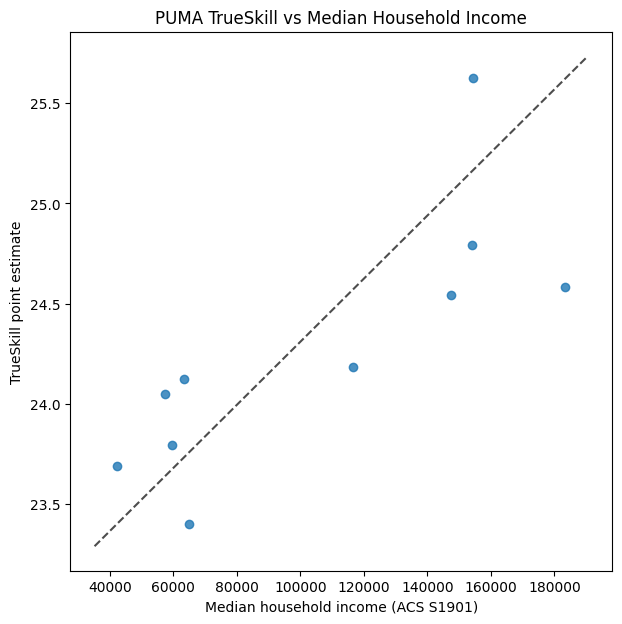

In [24]:
# Quick visualization for one univariate relationship.
import matplotlib.pyplot as plt

plot_df = puma_model_df.copy()

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.scatter(plot_df["median_income"], plot_df["ts_point_estimate"], alpha=0.8)
ax.set_title("PUMA TrueSkill vs Median Household Income")
ax.set_xlabel("Median household income (ACS S1901)")
ax.set_ylabel("TrueSkill point estimate")

# draw a perfect y=x line 
ax.plot(ax.get_xlim(), ax.get_ylim(), ls="--", c=".3")

plt.show()


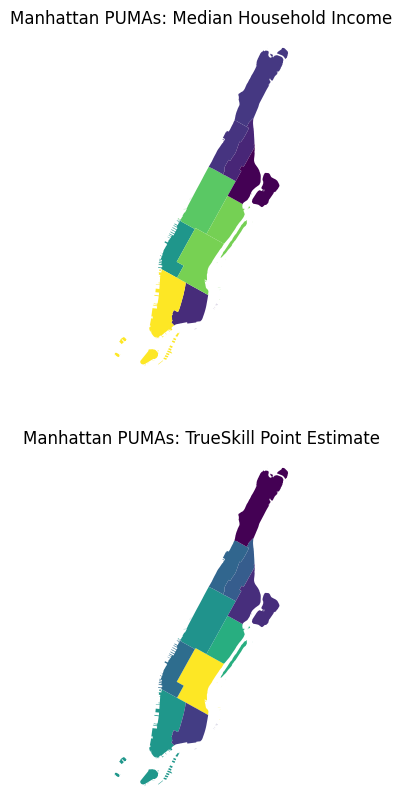

In [17]:
# Manhattan-only map comparison: median income vs TrueSkill.
import matplotlib.pyplot as plt

puma_ratings_gdf = puma_ratings_df.merge(puma_gdf, on="PUMA", how="left")
puma_covariates_gdf = puma_covariates.merge(puma_gdf, on="PUMA", how="left")

puma_ratings_gdf = gpd.GeoDataFrame(puma_ratings_gdf, geometry="geometry", crs=puma_gdf.crs)
puma_covariates_gdf = gpd.GeoDataFrame(puma_covariates_gdf, geometry="geometry", crs=puma_gdf.crs)

fig, ax = plt.subplots(2, 1, figsize=(10, 10))

puma_covariates_gdf.plot(column="median_income", cmap="viridis", ax=ax[0])
ax[0].set_title("Manhattan PUMAs: Median Household Income")
ax[0].set_axis_off()

puma_ratings_gdf.plot(column="ts_point_estimate", cmap="viridis", ax=ax[1])
ax[1].set_title("Manhattan PUMAs: TrueSkill Point Estimate")
ax[1].set_axis_off()

plt.show()



In [18]:
# Census tract mapping (Manhattan-only scope).
tract_gdf = gpd.read_file(
    "/share/pierson/matt/mllmsci/data/geo/2020_Census_Tracts_20260304.geojson"
)[["geoid", "boroname", "geometry"]].copy()

tract_gdf["geoid"] = tract_gdf["geoid"].astype(str)
tract_gdf["boroname"] = tract_gdf["boroname"].astype(str)
tract_gdf = tract_gdf.to_crs(recording_points.crs)

# Assign each recording to a tract.
recordings_with_tract = gpd.sjoin(
    recording_points,
    tract_gdf,
    how="left",
    predicate="within",
).drop(columns=["index_right"], errors="ignore")

recordings_with_tract["geoid"] = recordings_with_tract["geoid"].astype("string")

# Manhattan-only tract IDs from geometry source of truth.
manhattan_tracts = set(
    tract_gdf.loc[tract_gdf["boroname"].str.lower().eq("manhattan"), "geoid"]
    .dropna()
    .astype(str)
    .tolist()
)

recordings_with_tract.head()

,recording_id,lat,lon,geometry,geoid,boroname
0,W0DBPTNW,40.682931,-74.008453,POINT (981905.434 188086.737),36047005303,Brooklyn
1,W0DBPTNX,40.682936,-74.008512,POINT (981889.269 188088.399),36047005303,Brooklyn
2,W0DBPTNY,40.682924,-74.008568,POINT (981873.515 188084.234),36047005303,Brooklyn
3,W0EGPC2O,40.682934,-74.008436,POINT (981910.38 188087.759),36047005303,Brooklyn
4,W0EGPC2P,40.682941,-74.008493,POINT (981894.377 188090.203),36047005303,Brooklyn


In [19]:
# Census tract income covariates with identical Manhattan-only filtering.
acs_ct_path = "/share/pierson/matt/mllmsci/data/demo/ct/ACSST5Y2024.S1901-Data.csv"
acs_ct = pd.read_csv(acs_ct_path, header=1)

# NYC-ish filter first, then Manhattan-only (parallel to the PUMA section).
acs_ct_nyc = acs_ct[
    acs_ct["Geographic Area Name"].str.contains(r"County; New York$", case=False, na=False)
    | acs_ct["Geographic Area Name"].str.contains(r"New York County", case=False, na=False)
].copy()

acs_ct_nyc["geoid"] = acs_ct_nyc["Geography"].astype(str).str.extract(r"US(\d{11})$")

acs_ct_manhattan = acs_ct_nyc[
    acs_ct_nyc["Geographic Area Name"].str.contains(r"New York County", case=False, na=False)
].copy()
acs_ct_manhattan = acs_ct_manhattan[
    acs_ct_manhattan["geoid"].astype(str).isin(manhattan_tracts)
].copy()

income_cols_ct = {
    "mean_income": "Estimate!!Households!!Mean income (dollars)",
    "median_income": "Estimate!!Households!!Median income (dollars)",
}
for k, c in income_cols_ct.items():
    acs_ct_manhattan[k] = pd.to_numeric(
        acs_ct_manhattan[c].replace({"N": pd.NA, "-": pd.NA, "(X)": pd.NA}),
        errors="coerce",
    )

tract_covariates = acs_ct_manhattan[["geoid", "Geographic Area Name", *income_cols_ct.keys()]].copy()
tract_covariates.head()

,geoid,Geographic Area Name,mean_income,median_income
1166,36061000100,Census Tract 1; New York County; New York,NaN,NaN
1167,36061000201,Census Tract 2.01; New York County; New York,48856.0,37353.0
1168,36061000202,Census Tract 2.02; New York County; New York,69846.0,36688.0
1169,36061000500,Census Tract 5; New York County; New York,NaN,NaN
1170,36061000600,Census Tract 6; New York County; New York,63805.0,36893.0


In [20]:
# Manhattan-only tract pair aggregation, TrueSkill, and univariate regressions.
recording_to_tract = recordings_with_tract[["recording_id", "geoid"]].drop_duplicates("recording_id")

tract_matches = (
    matches.merge(
        recording_to_tract.rename(columns={"recording_id": "recording_id_a", "geoid": "tract_a"}),
        on="recording_id_a",
        how="left",
    )
    .merge(
        recording_to_tract.rename(columns={"recording_id": "recording_id_b", "geoid": "tract_b"}),
        on="recording_id_b",
        how="left",
    )
)

tract_matches = tract_matches.dropna(subset=["tract_a", "tract_b"]).copy()
tract_matches = tract_matches[
    tract_matches["tract_a"].astype(str).isin(manhattan_tracts)
    & tract_matches["tract_b"].astype(str).isin(manhattan_tracts)
].copy()
tract_matches = tract_matches[tract_matches["tract_a"] != tract_matches["tract_b"]].copy()

tract_pair_summary = (
    tract_matches.groupby(["tract_a", "tract_b"], as_index=False)
    .agg(
        n_comparisons=("relative_score", "size"),
        mean_relative_score=("relative_score", "mean"),
        median_relative_score=("relative_score", "median"),
    )
    .sort_values("n_comparisons", ascending=False)
)

tract_env = trueskill.TrueSkill(draw_probability=0.05)
tract_ratings = defaultdict(tract_env.create_rating)

for row in tract_matches.itertuples(index=False):
    a = str(row.tract_a)
    b = str(row.tract_b)
    score = int(row.relative_score)

    ra = tract_ratings[a]
    rb = tract_ratings[b]

    if score > 0:
        ra_new, rb_new = tract_env.rate_1vs1(ra, rb, drawn=False)
    elif score < 0:
        rb_new, ra_new = tract_env.rate_1vs1(rb, ra, drawn=False)
    else:
        ra_new, rb_new = tract_env.rate_1vs1(ra, rb, drawn=True)

    tract_ratings[a] = ra_new
    tract_ratings[b] = rb_new

tract_obs_counts = pd.concat([tract_matches["tract_a"], tract_matches["tract_b"]], axis=0).value_counts()

tract_ratings_df = pd.DataFrame(
    [
        {
            "geoid": tract,
            "mu": r.mu,
            "sigma": r.sigma,
            "ts_point_estimate": r.mu,
            "ts_conservative": r.mu - 3.0 * r.sigma,
            "n_comparisons": int(tract_obs_counts.get(tract, 0)),
        }
        for tract, r in tract_ratings.items()
    ]
).sort_values("ts_conservative", ascending=False)

tract_ratings_df = tract_ratings_df[tract_ratings_df["geoid"].astype(str).isin(manhattan_tracts)].copy()
tract_model_df = tract_ratings_df.merge(tract_covariates, on="geoid", how="inner")
tract_model_df = tract_model_df.dropna(subset=["ts_point_estimate", "mean_income", "median_income"]).copy()

y_ct = tract_model_df["ts_point_estimate"].astype(float)
ct_uni_models = {}
ct_rows = []

for cov in ["mean_income", "median_income"]:
    X_cov = sm.add_constant(tract_model_df[[cov]].astype(float))
    fit = sm.OLS(y_ct, X_cov).fit(cov_type="HC3")
    ct_uni_models[cov] = {"fit": fit, "X": X_cov}
    ct_rows.append(
        {
            "covariate": cov,
            "coef": fit.params[cov],
            "robust_se": fit.bse[cov],
            "p_value": fit.pvalues[cov],
            "r2": fit.rsquared,
            "adj_r2": fit.rsquared_adj,
            "n_obs": int(fit.nobs),
        }
    )

tract_uni_summary = pd.DataFrame(ct_rows).sort_values("p_value")
tract_uni_summary

,covariate,coef,robust_se,p_value,r2,adj_r2,n_obs
1,median_income,0.000006,7.500758e-07,1.268823e-15,0.200621,0.197826,288
0,mean_income,0.000003,4.947232e-07,1.488544e-09,0.140761,0.137756,288


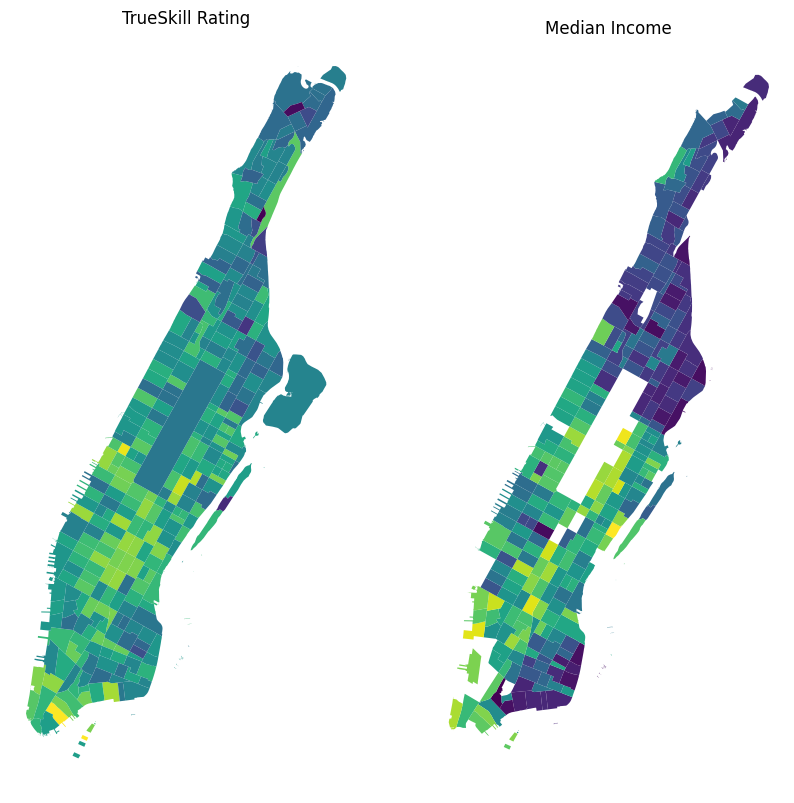

In [21]:
# tufte-style map of the tracts colored by TrueSkill rating and median income 
tract_ratings_gdf = tract_ratings_df.merge(tract_gdf, on="geoid", how="left")
tract_ratings_gdf = gpd.GeoDataFrame(tract_ratings_gdf, geometry="geometry", crs=tract_gdf.crs)

tract_covariates_gdf = tract_covariates.merge(tract_gdf, on="geoid", how="left")
tract_covariates_gdf = gpd.GeoDataFrame(tract_covariates_gdf, geometry="geometry", crs=tract_gdf.crs)

fig, ax = plt.subplots(1, 2, figsize=(10, 10))

tract_ratings_gdf.plot(column="ts_point_estimate", cmap="viridis", ax=ax[0])
tract_covariates_gdf.plot(column="median_income", cmap="viridis", ax=ax[1])

ax[0].set_title("TrueSkill Rating")
ax[1].set_title("Median Income")
ax[0].set_axis_off()
ax[1].set_axis_off()
plt.show()



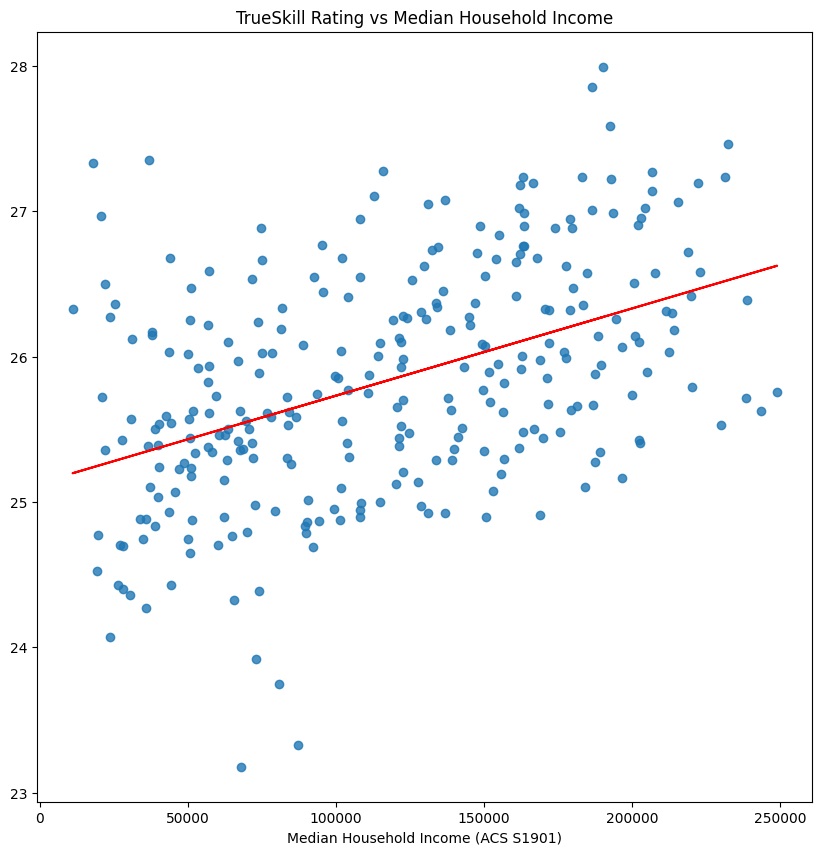

In [22]:
# scatter plot of TrueSkill rating vs. median income with regression line 
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(tract_model_df["median_income"], tract_model_df["ts_point_estimate"], alpha=0.8)
ax.set_title("TrueSkill Rating vs Median Household Income")
ax.set_xlabel("Median Household Income (ACS S1901)")

# add a regression line
x = tract_model_df["median_income"]
y = tract_model_df["ts_point_estimate"]
m, b = np.polyfit(x, y, 1)
ax.plot(x, m*x + b, color='red')

plt.show()
